# The tripolar north fold: do `diff` and `interp` work across the seam?

Tripolar ocean grids (MOM6, NEMO, Oceananigans) fold the northern edge of the
domain onto itself. The test of whether xgcm handles this correctly is simple:
**fields derived by `interp` and `diff` should be smooth across the fold** — no
spurious seam through the Arctic.

We check both operations on **three models**, each with real surface velocities
`u`/`v`, plotted on a North Polar Stereographic projection:

* **`interp`** — interpolate `u`,`v` to tracer (centre) points and plot the
  **surface current speed** $\sqrt{u^2+v^2}$ (the `v`→centre step crosses the seam);
* **`diff`** — the **relative vorticity** $\zeta = \partial v/\partial x -
  \partial u/\partial y$, with the derivatives divided by the cell spacings
  `dx`,`dy` (the $\partial u/\partial y$ step crosses the seam).

xgcm expresses the fold as a per-axis boundary, `boundary={"X": "periodic",
"Y": {"fold": <pivot>}}`. The pivot is set by each model's grid: **MOM6** and
**NEMO** use an F-point (`"corner"`) pivot, **Oceananigans** a U-point (`"u"`)
pivot. (Verified independently: xgcm's reconstructed fold halos match
Oceananigans' own zipper exactly for the tracer and both velocity components.)

> **Dependencies** — the MOM6/NEMO sections read CMIP6 from the Pangeo cloud
> (`pip install zarr gcsfs`); plots use `cartopy`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm

from xgcm import Grid

so = {"storage_options": {"token": "anon"}}
EARTH_RADIUS = 6371e3

## Helpers

`package` puts a model's `u`,`v` on a common staggered index grid (`u` at the
X-face, `v` at the Y-face, tracer at the centre). `cell_spacings` builds the
zonal/meridional distances `dx`,`dy` from the geographic coordinates (great-circle
distances between neighbouring points). `surface_speed` and `relative_vorticity`
do the fold-aware `interp`/`diff`; `polar_panels` draws one field per model.

In [2]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle a model's surface velocities onto a common staggered index grid.'''
    a = lambda x: np.asarray(getattr(x, "values", x))
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label)


def _haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(h))


def cell_spacings(lon, lat):
    '''dx, dy [m] at the cell corner, from neighbouring centre coordinates.'''
    lonE = np.concatenate([lon, lon[:, :1]], axis=1)   # periodic wrap in X
    latE = np.concatenate([lat, lat[:, :1]], axis=1)
    dx = _haversine(lonE[:, :-1], latE[:, :-1], lonE[:, 1:], latE[:, 1:])
    dy = np.empty_like(lat)
    dy[:-1] = _haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])
    dy[-1] = dy[-2]
    return (xr.DataArray(dx, dims=["y_f", "x_f"]), xr.DataArray(dy, dims=["y_f", "x_f"]))


def _grid(coords, edge, fold):
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                boundary={"X": "periodic", "Y": {"fold": fold}}, autoparse_metadata=False)


def surface_speed(m):
    '''sqrt(u^2 + v^2) interpolated to tracer points; v->centre crosses the fold.'''
    g = _grid(m["coords"], "left", m["fold"])     # left faces: top centre pulls the folded face
    uc = g.interp(m["u"], "X")
    vc = g.interp({"Y": m["v"]}, "Y", other_component={"X": m["u"]}, boundary="extend")
    return np.hypot(uc, vc).where(lambda s: s > 0)


def relative_vorticity(m):
    '''zeta = dv/dx - du/dy at the cell corner; du/dy crosses the fold.'''
    g = _grid(m["coords"], "right", m["fold"])    # right faces: corner row reaches the seam
    dx, dy = cell_spacings(m["lon"], m["lat"])
    dvdx = g.diff(m["v"], "X", boundary="fill") / dx
    dudy = g.diff({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="fill") / dy
    return dvdx - dudy


def polar_panels(fields, models, *, norm=None, cmap, label, title, sym=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.6),
                             subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
    for ax, f, m in zip(axes, fields, models):
        ax.set_extent([-180, 180, 55, 90], ccrs.PlateCarree())
        arr = np.ma.masked_invalid(np.asarray(f.values))
        kw = dict(transform=ccrs.PlateCarree(), shading="nearest", cmap=cmap)
        if sym:
            lim = float(np.nanpercentile(np.abs(arr.filled(np.nan)), 99))
            kw.update(vmin=-lim, vmax=lim)
        else:
            kw["norm"] = norm
        pm = ax.pcolormesh(m["lon"], m["lat"], arr, **kw)
        ax.coastlines(linewidth=0.4, color="0.5")
        ax.gridlines(color="k", alpha=0.2, linewidth=0.3)
        ax.set_title(m["label"], fontsize=10)
        fig.colorbar(pm, ax=ax, shrink=0.55, pad=0.06, label=label)
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## Load the three models

Real CMIP6 surface velocities for MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from
the Pangeo cloud, and a realistic 1° ClimaOcean/Oceananigans surface snapshot.
CMIP6 masks its redundant northern row, so we drop it before folding.

In [3]:
def _cmip6_surface(source_id, version, fold, label):
    base = (f"gs://cmip6/CMIP6/CMIP/{{inst}}/{source_id}/historical/"
            f"r1i1p1f1/Omon/{{var}}/gn/{version}/")
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]

    def s(var):
        ds = xr.open_dataset(base.format(inst=inst, var=var), engine="zarr", backend_kwargs=so)
        return ds[var].isel(time=0).isel({ds[var].dims[1]: 0})   # first level

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    grid_ds = xr.open_dataset(base.format(inst=inst, var="uo"), engine="zarr", backend_kwargs=so)
    lonname = "lon" if "lon" in grid_ds.variables else "nav_lon"
    latname = "lat" if "lat" in grid_ds.variables else "nav_lat"
    lon = grid_ds[lonname].isel(y=slice(0, -1)).values
    lat = grid_ds[latname].isel(y=slice(0, -1)).values
    return package(uo, vo, lon, lat, fold, label)


def _oceananigans():
    o = xr.open_dataset("oceananigans_tripolar.nc")
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]

## `interp` across the fold: surface current speed

The speed is smooth right across the Arctic — including the fold — for all three
models, so the velocity interpolation reaches correctly across the seam.

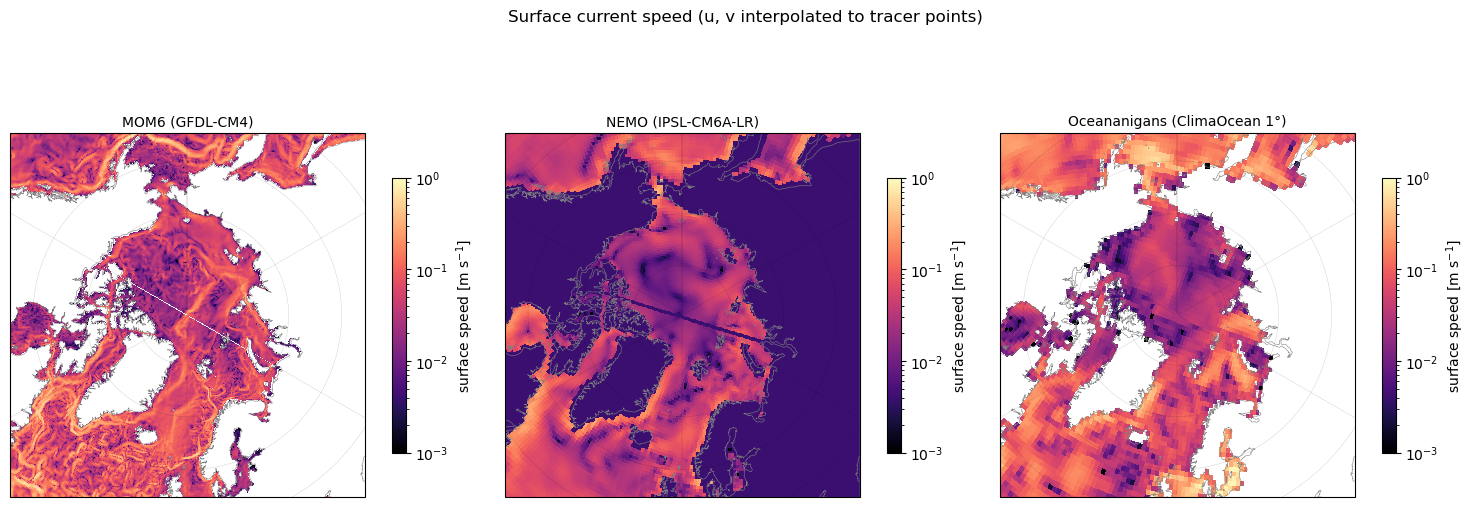

In [4]:
speeds = [surface_speed(m) for m in models]
polar_panels(speeds, models, norm=LogNorm(vmin=1e-3, vmax=1.0), cmap="magma",
             label="surface speed [m s$^{-1}$]",
             title="Surface current speed (u, v interpolated to tracer points)")

## `diff` across the fold: relative vorticity

Relative vorticity $\zeta = \partial v/\partial x - \partial u/\partial y$ (s$^{-1}$),
with the derivatives divided by the cell spacings. It too varies smoothly across
the fold — no seam — confirming the fold-aware differencing.

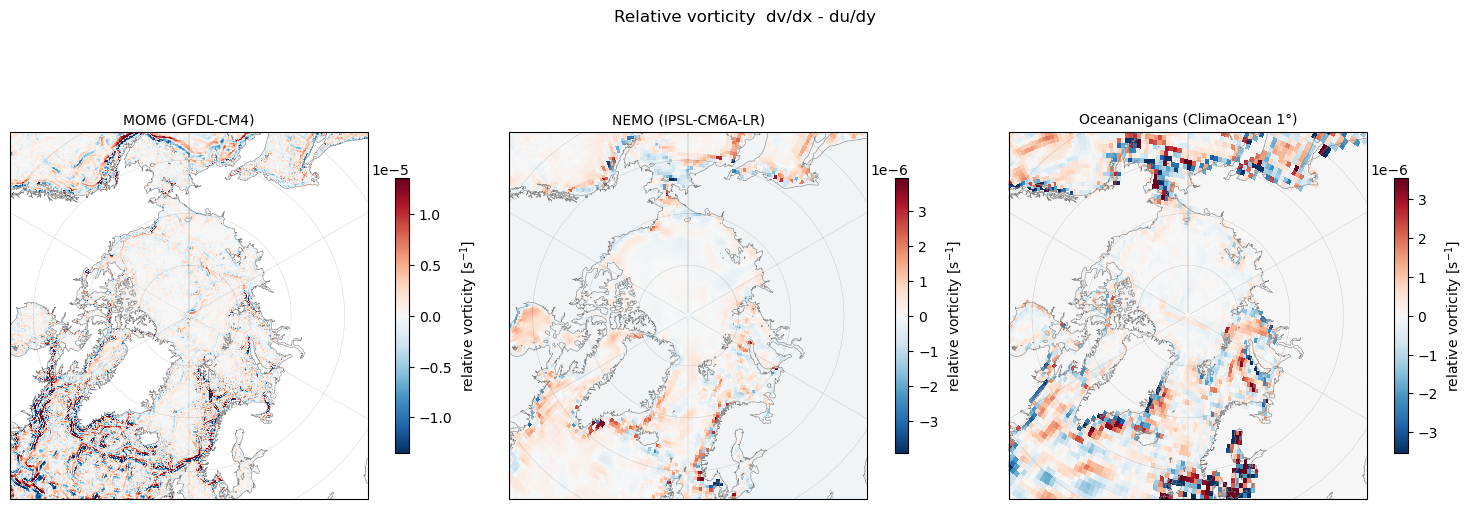

In [5]:
vorts = [relative_vorticity(m) for m in models]
polar_panels(vorts, models, cmap="RdBu_r", sym=True,
             label="relative vorticity [s$^{-1}$]",
             title="Relative vorticity  dv/dx - du/dy")

## Why the fold is needed

Without the fold (treating `Y` as a plain filled boundary) the same vorticity
develops a spurious discontinuity along the seam. The difference between the
naive and fold-aware vorticity is confined to the single fold row.

In [6]:
m = models[2]   # Oceananigans
g_fold = _grid(m["coords"], "right", m["fold"])
g_naive = Grid(xr.Dataset(coords=m["coords"]),
               coords={"X": {"center": "x_c", "right": "x_f"},
                       "Y": {"center": "y_c", "right": "y_f"}},
               boundary={"X": "periodic", "Y": "fill"}, autoparse_metadata=False)
dx, dy = cell_spacings(m["lon"], m["lat"])
dvdx = g_fold.diff(m["v"], "X", boundary="fill") / dx
z_fold = dvdx - g_fold.diff({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="fill") / dy
z_naive = dvdx - g_naive.diff(m["u"], "Y", boundary="fill", fill_value=0.0) / dy
diff = (z_naive - z_fold).values
print("max|naive - fold|  at the seam row =", float(np.nanmax(np.abs(diff[-1]))))
print("max|naive - fold|  below the seam  =", float(np.nanmax(np.abs(diff[:-1]))))

max|naive - fold|  at the seam row = 2.0527115128168626e-06
max|naive - fold|  below the seam  = 0.0


## Takeaway

For all three tripolar conventions (MOM6/NEMO `"corner"`, Oceananigans `"u"`),
both `interp` (surface speed) and `diff` (relative vorticity) produce fields that
are **smooth across the North fold** — the seam is invisible — while the naive
(no-fold) calculation leaves a discontinuity confined to the fold row. xgcm's
`boundary={"Y": {"fold": ...}}` mirrors the seam and sign-flips folded velocities
so that the standard staggered-grid operators just work across the pole.

See the [grid topology](../grid_topology.md) docs and [`03_MOM6.ipynb`](03_MOM6.ipynb).